In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

DATA_PATH = Path("../data/raw/diabetes.csv")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
target = "Outcome"

X = df.drop(columns=target)
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\ny distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True))

X shape: (768, 8)
y shape: (768,)

X columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

y distribution:
Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

X_train shape: (614, 8)
X_test shape: (154, 8)

Train target distribution:
Outcome
0    400
1    214
Name: count, dtype: int64
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Test target distribution:
Outcome
0    100
1     54
Name: count, dtype: int64
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


Шаг: строим baseline через DummyClassifier

In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
}

dummy_clf = DummyClassifier(strategy="most_frequent")

dummy_cv_results = cross_validate(
    dummy_clf,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
)

dummy_cv_summary = (
    pd.DataFrame(dummy_cv_results)
    .filter(like="test_")
    .agg(["mean", "std"])
    .T
)

dummy_cv_summary

,mean,std
test_accuracy,0.651473,0.002384
test_precision,0.000000,0.000000
test_recall,0.000000,0.000000
test_f1,0.000000,0.000000
test_roc_auc,0.500000,0.000000


Следующий шаг: Logistic Regression как первый ML-baseline

In [5]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

suspicious_zero_cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

def handle_suspicious_zeros(X):
    X = X.copy()

    X["Insulin_missing"] = (X["Insulin"] == 0).astype(int)
    X["SkinThickness_missing"] = (X["SkinThickness"] == 0).astype(int)

    X[suspicious_zero_cols] = X[suspicious_zero_cols].replace(0, np.nan)

    return X

logreg_pipeline = Pipeline(
    steps=[
        ("zero_handler", FunctionTransformer(handle_suspicious_zeros, validate=False)),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000)),
    ]
)

logreg_cv_results = cross_validate(
    logreg_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
)

logreg_cv_summary = (
    pd.DataFrame(logreg_cv_results)
    .filter(like="test_")
    .agg(["mean", "std"])
    .T
)

logreg_cv_summary

,mean,std
test_accuracy,0.789871,0.016185
test_precision,0.760518,0.063618
test_recall,0.588815,0.034583
test_f1,0.661436,0.017370
test_roc_auc,0.843462,0.017969


In [6]:
comparison = pd.concat(
    {
        "dummy": dummy_cv_summary["mean"],
        "logreg": logreg_cv_summary["mean"],
    },
    axis=1,
)

comparison["absolute_improvement"] = comparison["logreg"] - comparison["dummy"]

comparison

,dummy,logreg,absolute_improvement
test_accuracy,0.651473,0.789871,0.138398
test_precision,0.000000,0.760518,0.760518
test_recall,0.000000,0.588815,0.588815
test_f1,0.000000,0.661436,0.661436
test_roc_auc,0.500000,0.843462,0.343462


In [7]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_train_pred_oof = cross_val_predict(
    logreg_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict",
)

cm = confusion_matrix(y_train, y_train_pred_oof)

cm

array([[359,  41],
       [ 88, 126]])

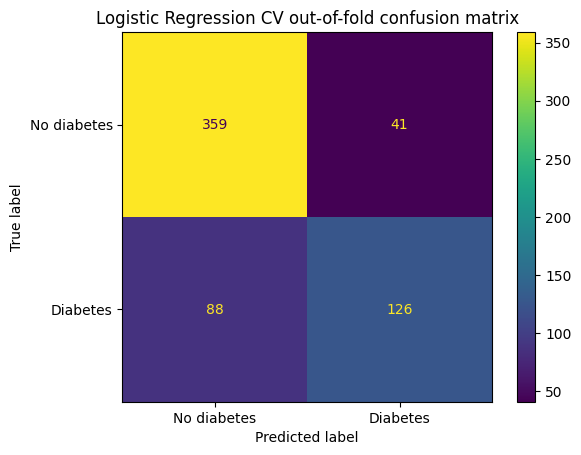

In [8]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No diabetes", "Diabetes"],
)

disp.plot()
plt.title("Logistic Regression CV out-of-fold confusion matrix")
plt.show()